# Импрорты и нужные классы

In [1]:
import sys
import os
import torch
import copy
import numpy as np
from dotenv import load_dotenv

sys.path.append(os.path.join('..', '..'))
env_file = os.path.join('..', '..', '.env')
load_dotenv(env_file)
rowGlam_type = os.environ['ROW_GLAM_TYPE'] # custom or base
name_dataset = os.environ['NAME_DATASET']
name_test_dataset = os.environ['NAME_TEST_DATASET']
dataset_path = os.environ['DATASET_PATH']
test_path = os.environ['TEST_PATH']
test_coco_path = os.environ['TEST_COCO_PATH']
coco_path = os.environ['COCO_PATH']
cache_pdf = 'tmp_base_feature'

In [2]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.utils.cacher import Cacher
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.utils.imbalance import calculate_imbalance
from rows2regionsGLAM.utils.tester import collect_maps, print_map_table

from rows2regionsGLAM.models.rowGLAM_base import TorchModelBase, PARAMS_BASE
from rows2regionsGLAM.models.rowGLAM_custom import TorchModel, PARAMS

from rows2regionsGLAM.tokenizers.font_tokenizer import RowGLAMTokenizer
from rows2regionsGLAM.converters import Rows2Regions
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from pager.page_model.sub_models.dtype import ImageSegment
from pager.page_model.sub_models import RegionModel, RowsModel

In [3]:
import datetime 
loger = Loger(f'log_{datetime.datetime.now()}.txt')
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})
coco_manager = COCOManager(conf={"loger": loger, "coco_path": coco_path})
ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

pdf2torch_dict = Cacher({
    "loger": loger,
    "pdf_manager": pdf_manager,
    "row_manager": row_manager,
    "tokenizer": tokenizer
})

# Проверка чтения файла

In [4]:
json_true_regions, CLASSES = coco_manager.get_regions_from_json()

In [5]:
CLASSES[3] = "text"
CLASSES

{1: 'text', 2: 'title', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

In [6]:
file_names = list(json_true_regions.keys())
file_names.sort()

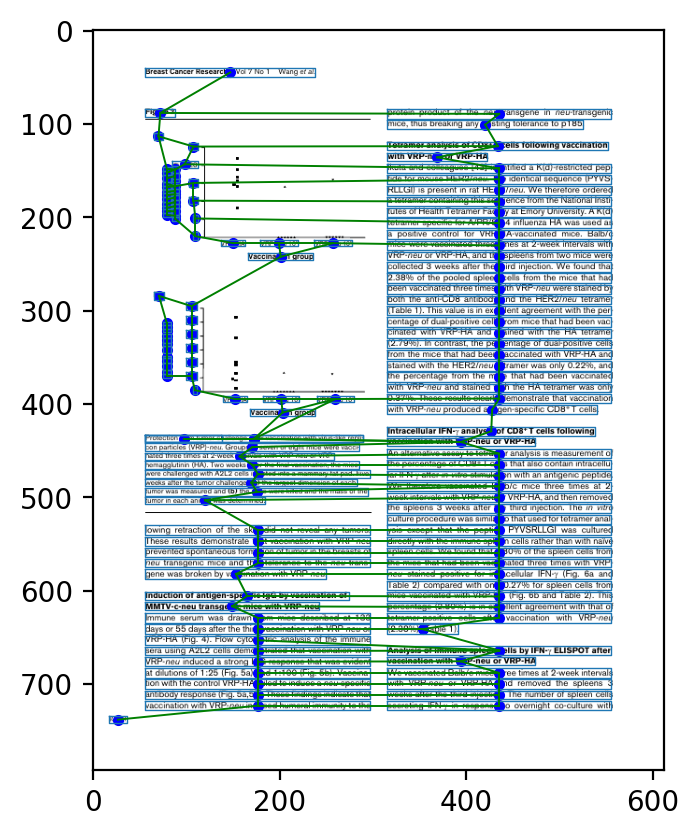

In [7]:
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(dataset_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json, pdf_img)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

# Сохранение датасета

In [9]:
dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": dataset_path,
    "coco_file": coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(dataset)
for i, d in enumerate(dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

# Отрисовска файла из датасета

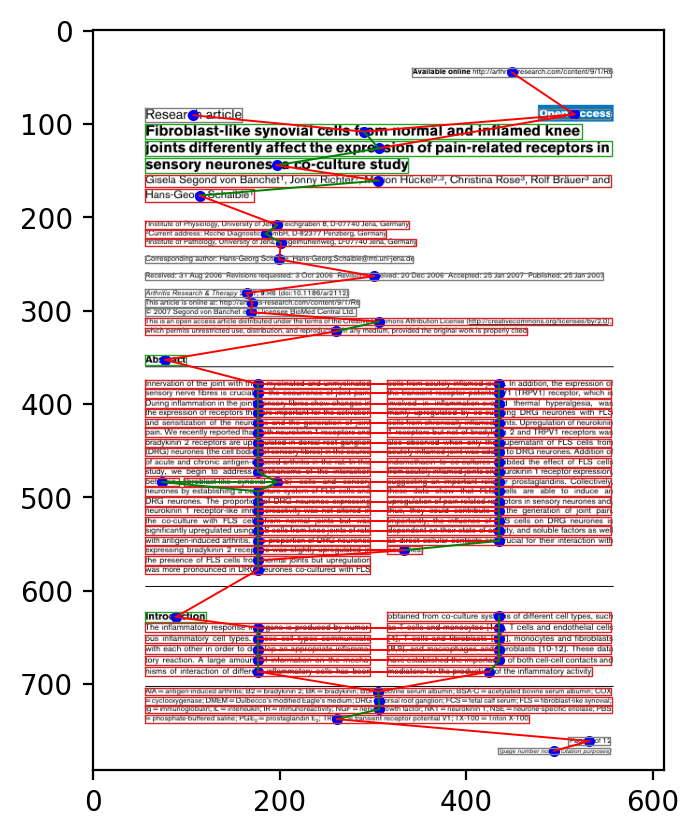

In [10]:
torch_dict2 = dataset[100]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict2, markup=True)

# Регионы --------------------------------------------------------------
# ann = coco_manager.get_regions_from_json()
# regions = ann[torch_dict2['file_name'] + ".pdf"]['regions']

# for reg in regions:
#     seg = ImageSegment(dict_p_size=reg['segment'])
#     seg.plot()

# Параметры модели

In [17]:
model_name = 'row2region_GLAM_font_custom'

if rowGlam_type == "base":
    model_params = copy.deepcopy(PARAMS_BASE)
elif rowGlam_type == "custom":
    # model_params = copy.deepcopy(PARAMS)
    model_params  = {
        "node_featch": 15,
        "edge_featch": 4,
        "learning_rate": 0.001,
        "model_type" : 2,
        "concat_gcn" : True,
        "mlp_pred":[
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 256},
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 128}],
        "gcn_node":[
             {"linear_in" : -1, "linear_out" : 256, "batch_norm" : True,  "activation" : "gelu", "aggregation" : "tag", "K" : 3,  "size":128},
             {"linear_in" : -1, "linear_out" : 256, "batch_norm" : False, "activation" : "gelu", "aggregation" : "tag", "K" : 3,  "size":64}],
        "mlp_node_class":[
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 256},
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 128},
             {"in" : -1, "batch_norm" : False, "activation" : "softmax", "out" : 6}],
        "mlp_node_pred":[
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 256},
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 256},
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 128}],
        "gcn_node_post":[
             {"linear_in" : -1, "linear_out" : 256, "batch_norm" : True,  "activation" : "gelu", "aggregation" : "tag", "K" : 3,  "size":128},
             {"linear_in" : -1, "linear_out" : 256, "batch_norm" : False, "activation" : "gelu", "aggregation" : "tag", "K" : 3,  "size":128}],
        "mlp_node_edge":[
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 256},
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 128},
             {"in" : -1, "batch_norm" : False, "activation" : None,   "out" : 128}],
        "mlp_edge_class":[
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 256},
             {"in" : -1, "batch_norm" : False, "activation" : "gelu", "out" : 64},
             {"in" : -1, "batch_norm" : False, "activation" : None,   "out" : 1}],
        "seg_k": 0.5,
        "loss_params": {
            "edge_coef": 0.8,
            "node_coef": 0.2,
        },
        "sigmoidEdge": False,
        "NodeClasses": len(CLASSES)
    }
    
model_params["NodeClasses"] = len(CLASSES)
model_params["node_featch"] = 18
model_params["epochs"] = 10
model_params["batch_size"] = 64

In [18]:
# Дисбаланс классов ------------------------------------
publaynet_imbalance, edge_imbalance = calculate_imbalance(dataset)

print(publaynet_imbalance, edge_imbalance)

model_params['loss_params']['publaynet_imbalance'] = publaynet_imbalance
model_params['loss_params']['edge_imbalance'] = edge_imbalance

model_params

[0.07937020808458328, 0.007516949903219938, 0.40734851360321045, 0.2979268431663513, 0.01713326945900917, 0.19070428609848022] 0.3884359300136566


{'node_featch': 18,
 'edge_featch': 4,
 'learning_rate': 0.001,
 'model_type': 2,
 'concat_gcn': True,
 'mlp_pred': [{'in': -1,
   'batch_norm': False,
   'activation': 'gelu',
   'out': 256},
  {'in': -1, 'batch_norm': False, 'activation': 'gelu', 'out': 128}],
 'gcn_node': [{'linear_in': -1,
   'linear_out': 256,
   'batch_norm': True,
   'activation': 'gelu',
   'aggregation': 'tag',
   'K': 3,
   'size': 128},
  {'linear_in': -1,
   'linear_out': 256,
   'batch_norm': False,
   'activation': 'gelu',
   'aggregation': 'tag',
   'K': 3,
   'size': 64}],
 'mlp_node_class': [{'in': -1,
   'batch_norm': False,
   'activation': 'gelu',
   'out': 256},
  {'in': -1, 'batch_norm': False, 'activation': 'gelu', 'out': 128},
  {'in': -1, 'batch_norm': False, 'activation': 'softmax', 'out': 6}],
 'mlp_node_pred': [{'in': -1,
   'batch_norm': False,
   'activation': 'gelu',
   'out': 256},
  {'in': -1, 'batch_norm': False, 'activation': 'gelu', 'out': 256},
  {'in': -1, 'batch_norm': False, 'act

# Обучение модели

In [19]:
trainer_pub = Trainer(conf={"loger": loger, "params": model_params, "model_name": model_name})
trainer_pub.start_train(5, dataset)


            DATASET INFO:
            count row: 10000
            first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([104, 104])
            	 nodes_feature:torch.Size([104, 18])
            	 edges_feature:torch.Size([151, 4])
            	 true_edges:torch.Size([151])
            end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([107, 107])
            	 nodes_feature:torch.Size([107, 18])
            	 edges_feature:torch.Size([108, 4])
            	 true_edges:torch.Size([108])
        node_featch:	18
edge_featch:	4
learning_rate:	0.001
model_type:	2
concat_gcn:	True
mlp_pred:	[{'in': -1, 'batch_norm': False, 'activation': 'gelu', 'out': 256}, {'in': -1, 'batch_norm': False, 'activation': 'gelu', 'out': 128}]
gcn_node:	[{'linear_in': -1, 'linear_out': 256, 'batch_norm': True, 'activation': 'gelu', 'aggregation': 'tag', 'K': 3, 'size': 128}, {'linear_

/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/utils/_spmm.py:71: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  src = src.to_sparse_csr()
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Время обучения batch'а 1.41 сек                                   
'X'75 % Batch loss=0.0889                                         
'X'31 % Batch loss=0.1345                                         
========== EPOCH #1 ========== (0.2208/0.0998)                    
Время обучения epoch 121.87 сек
'X'75 % Batch loss=0.0834                                         
'X'31 % Batch loss=0.0945                                         
========== EPOCH #2 ========== (0.0854/0.0778)                    
'X'75 % Batch loss=0.0624                                         
'X'31 % Batch loss=0.0899                                         
========== EPOCH #3 ========== (0.0704/0.0660)                    
'X'75 % Batch loss=0.0454                                         
'X'31 % Batch loss=0.0994                                         
========== EPOCH #4 ========== (0.0624/0.0643)                    
'X'75 % Batch loss=0.0472                                         
'X'31 % Batch loss=0.0909     

# Проверка работы модели

In [22]:
model_params['sigmoidEdge'] = True
if rowGlam_type == "custom":
    model_params['mlp_edge_class'][-1]['activation'] = None

if rowGlam_type == "base":
    model = TorchModelBase(model_params)
elif rowGlam_type == "custom":
    model = TorchModel(model_params)

model.load_state_dict(torch.load(model_name, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions = Rows2Regions({
    'model':model, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True,
    'classes': CLASSES
})

/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


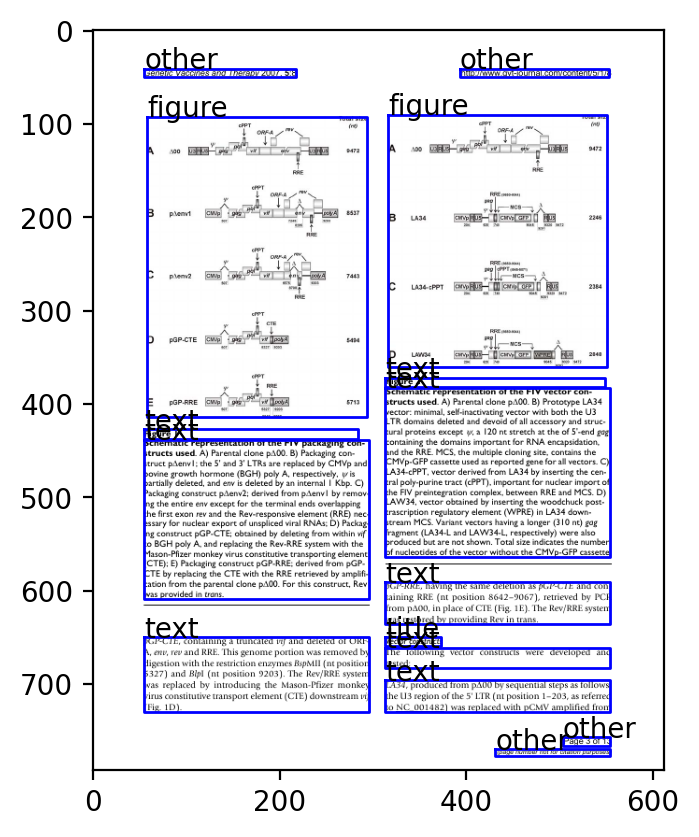

In [23]:
torch_dict2 = dataset[126]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [24]:
test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
    }
)

In [25]:
loger("Start Test")
loger.time_log()

N = len(test_dataset)
for i, d in enumerate(test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

In [26]:
tester = Tester(conf={
    "loger": loger, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions})

metrics = tester.calculate_target_and_preds(
    test_dataset, 
    name_dataset, 
    name_test_dataset, 
    dataset_path, 
    test_path
)

/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packa

/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packa

/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packa

...

/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packa

/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packa

/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/project/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [28]:
tester.print_result(metrics)

mAP@IoU[0.50:0.95]   :0.58775783
threshold_05--------------------
precision_row       :0.8578
recall_row          :0.8215
f1_row              :0.8393
precision_word      :0.8213
recall_word         :0.7864
f1_word             :0.8035
threshold_95--------------------
precision_row       :0.7846
recall_row          :0.7543
f1_row              :0.7691
precision_word      :0.7450
recall_word         :0.7158
f1_word             :0.7301



In [ ]:
mAP@IoU[0.50:0.95]   :0.52044123
==================================================
threshold_05--------------------
precision_row       :0.8745
recall_row          :0.7442
f1_row              :0.8041
precision_word      :0.8312
recall_word         :0.7130
f1_word             :0.7676
threshold_95--------------------
precision_row       :0.7275
recall_row          :0.6222
f1_row              :0.6707
precision_word      :0.6884
recall_word         :0.5949
f1_word             :0.6382